
#***Customer Churn Prediction***

#***🧠 Problem Statement***
Customer churn is a major concern for businesses, especially in industries like telecom,
banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.
In this project, the goal is to build a Machine Learning classification model that predicts
whether a customer will leave the company (Churn: Yes/No) based on features such as:
#● Customer Age
#● Gender
#● Tenure
#● Contract Type
#● Payment Method
#● Internet Service
#● Tech Support
#● Online Security
#● Customer Support Calls
Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting customer churn.

##***🎯 Objective***
The objective of this task is to:
● Understand and explore the customer dataset
● Perform data preprocessing (missing values, duplicates, outliers)
● Conduct Exploratory Data Analysis (EDA)
● Apply encoding and feature scaling
● Train multiple classification algorithms
● Evaluate models using classification metrics
● Perform cross-validation and hyperparameter tuning
● Select the best-performing model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("telecom_churn_data.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [6]:
df.isnull().sum()

,0
customerID,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df.drop("customerID",axis=1,inplace=True)

In [8]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [9]:
df.isnull().sum()

,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [10]:
#gender
df["gender"]=df["gender"].fillna(df["gender"].mode()[0])

In [11]:
df["PaperlessBilling"]=df['PaperlessBilling'].fillna(df['PaperlessBilling'].mode()[0])

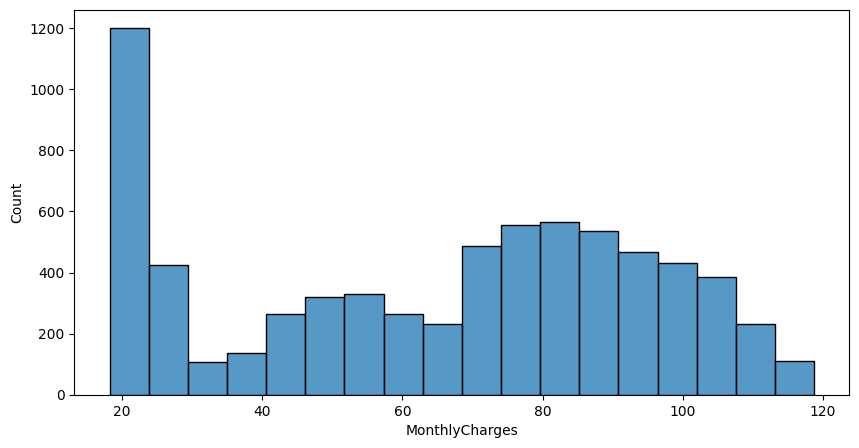

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df,x="MonthlyCharges")
plt.show()

In [13]:
df["MonthlyCharges"].skew()

np.float64(-0.22028439456532767)

In [14]:
df['MonthlyCharges']=df['MonthlyCharges'].fillna(df['MonthlyCharges'].mean())

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


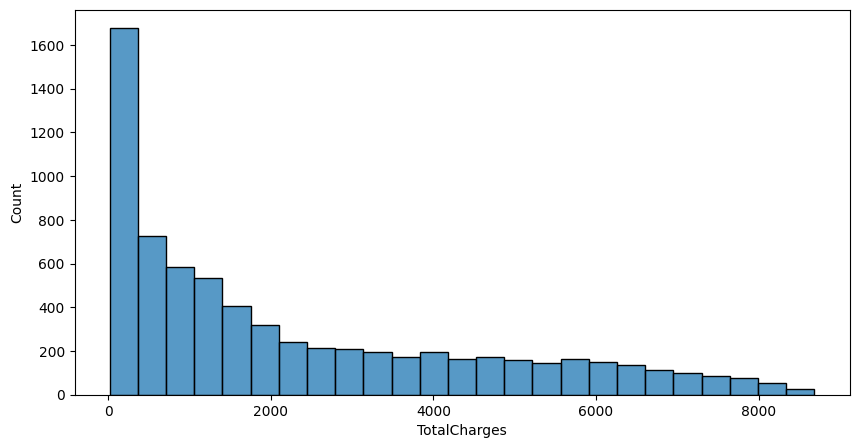

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df,x="TotalCharges")
plt.show()

In [17]:
df['TotalCharges'].skew()

np.float64(0.9616058347613503)

In [18]:
df['TotalCharges']=df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [19]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [20]:
df.duplicated().sum()

np.int64(22)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
num_cols=df.select_dtypes(include=['int64','float64'])
cat_cols=df.select_dtypes(include=['object'])

In [23]:
num_cols

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


In [24]:
cat_cols

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
7039,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
7040,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
7041,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


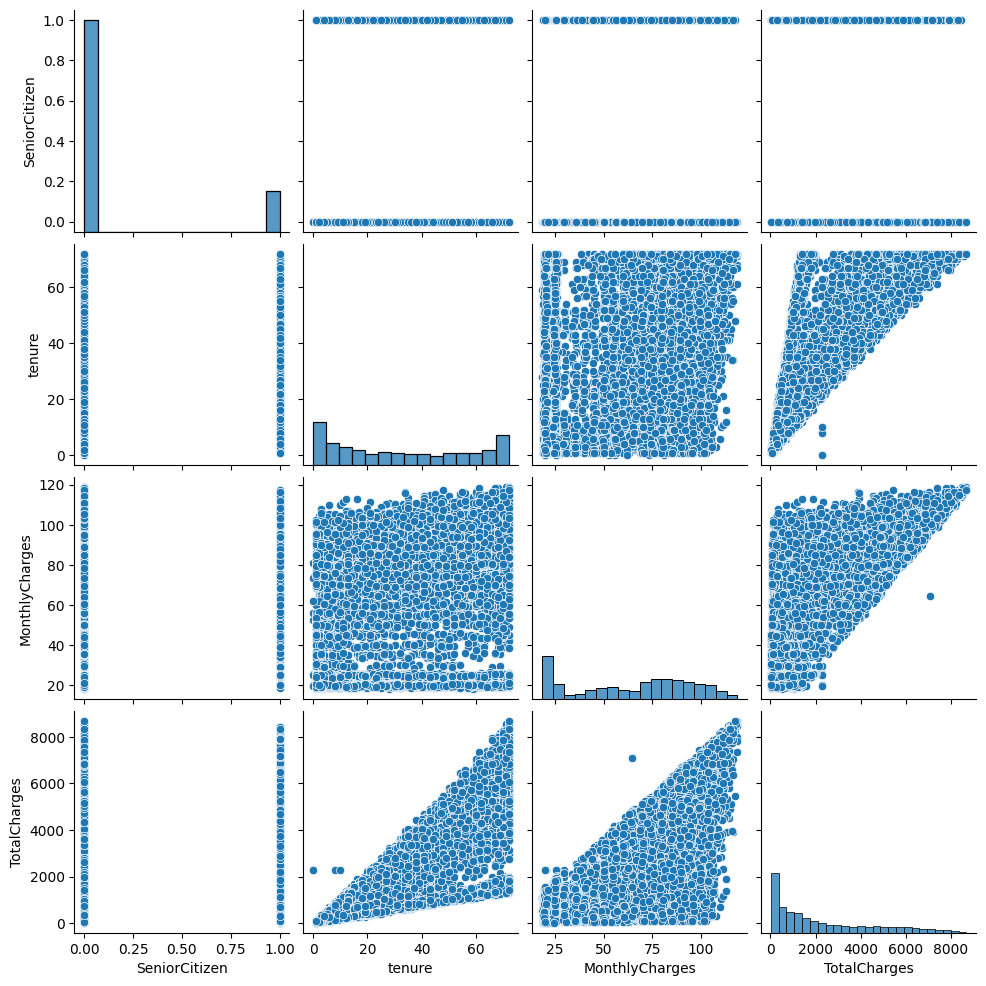

In [25]:
#EDA
sns.pairplot(df)
plt.show()

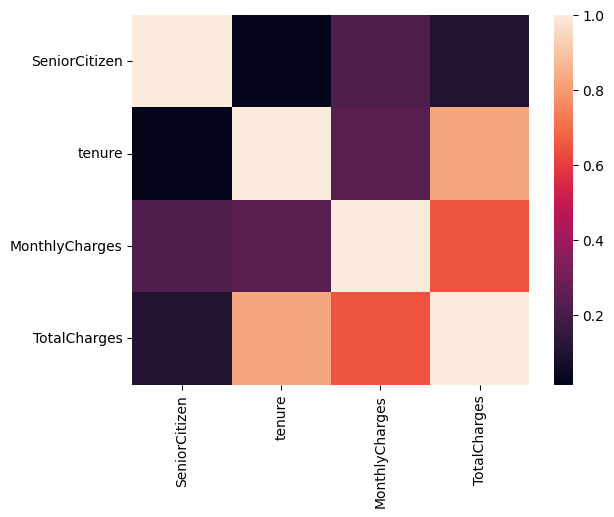

In [26]:
sns.heatmap(df.corr(numeric_only=True))
plt.show()

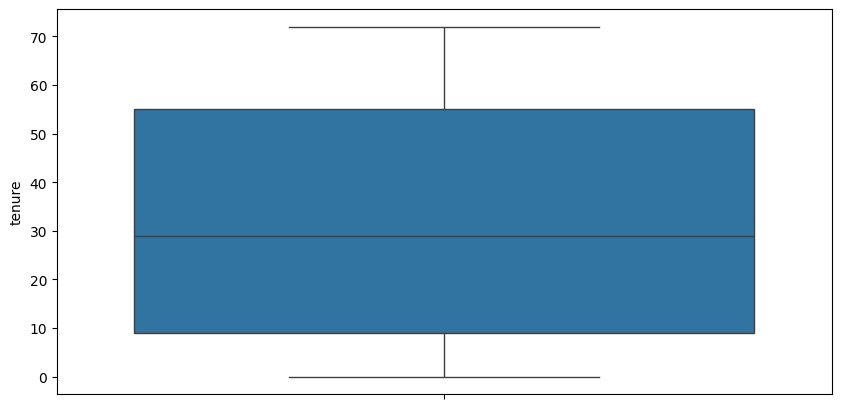

In [27]:
#check for outliers
#tenure
#monthlycharges
#totalcharges
plt.figure(figsize=(10,5))
sns.boxplot(df["tenure"])
plt.show()

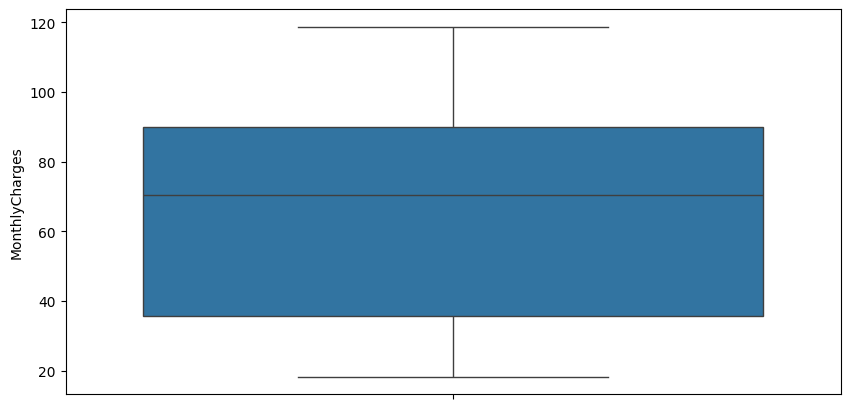

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(df["MonthlyCharges"])
plt.show()

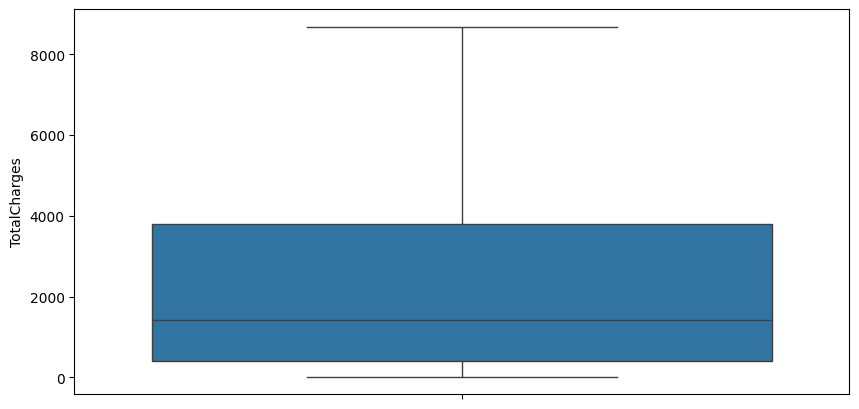

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(df["TotalCharges"])
plt.show()


In [30]:
#no outliers

In [31]:
df=pd.get_dummies(df,columns=['gender'],dtype='int')

In [32]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['partner']=le.fit_transform(df['Partner'])
df['dependents']=le.fit_transform(df['Dependents'])
df['phoneService']=le.fit_transform(df['PhoneService'])
df['onlineSecurity']=le.fit_transform(df['OnlineSecurity'])
df['onlineBackup']=le.fit_transform(df['OnlineBackup'])
df['deviceProtection']=le.fit_transform(df['DeviceProtection'])
df['techSupport']=le.fit_transform(df['TechSupport'])
df['streamingTV']=le.fit_transform(df['StreamingTV'])
df['streamingMovies']=le.fit_transform(df['StreamingMovies'])
df['paperlessBilling']=le.fit_transform(df['PaperlessBilling'])
df['churn']=le.fit_transform(df['Churn'])

In [33]:
df.drop(columns=["Partner",'Dependents','PhoneService','OnlineBackup','OnlineSecurity','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn'],axis=1,inplace=True)

In [34]:
df.head()

,SeniorCitizen,tenure,MultipleLines,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,gender_Female,gender_Male,...,dependents,phoneService,onlineSecurity,onlineBackup,deviceProtection,techSupport,streamingTV,streamingMovies,paperlessBilling,churn
0,0,1,No phone service,DSL,Month-to-month,Electronic check,29.85,29.85,1,0,...,0,0,0,2,0,0,0,0,1,0
1,0,34,No,DSL,One year,Mailed check,56.95,1889.50,0,1,...,0,1,2,0,2,0,0,0,0,0
2,0,2,No,DSL,Month-to-month,Mailed check,53.85,108.15,0,1,...,0,1,2,2,0,0,0,0,1,1
3,0,45,No phone service,DSL,One year,Bank transfer (automatic),42.30,1840.75,0,1,...,0,0,2,0,2,2,0,0,0,0
4,0,2,No,Fiber optic,Month-to-month,Electronic check,70.70,151.65,1,0,...,0,1,0,0,0,0,0,0,1,1
